Link dataset: https://www.kaggle.com/datasets/fedesoriano/traffic-prediction-dataset

Per questa analisi è stato scelto il Traffic Prediction Dataset. Il dataset originale è strutturato su quattro fetures principali: `ID` (identificativo univoco), `DateTime` (data e ora della misurazione), `Junction` (l'incrocio di riferimento) e `Vehicles` (il numero di veicoli transitati).

L'obiettivo del progetto è addestrare un modello di predizione in grado di stimare il volume di traffico (variabile target Vehicles). Attraverso l'elaborazione della data, il modello imparerà a prevedere l'intensità del traffico basandosi sulla posizione (lo specifico incrocio) e sulle variabili temporali (l'orario della giornata e la tipologia di giorno, ad esempio feriale o festivo).

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('archive/traffic.csv')
display(df.head(10))


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
5,2015-11-01 05:00:00,1,6,20151101051
6,2015-11-01 06:00:00,1,9,20151101061
7,2015-11-01 07:00:00,1,8,20151101071
8,2015-11-01 08:00:00,1,11,20151101081
9,2015-11-01 09:00:00,1,12,20151101091


Come si può notare dalle informazioni generali, il dataset include la variabile DateTime. Poiché i modelli di Machine Learning non sono in grado di elaborare direttamente date in formato testuale, è necessario applicare una trasformazione.
Procederemo dunque a scomporre la feature DataTime in alcune nuove features (`Year`, `Month`, `Day`, `Hour`, `DayOfWeek`).
Questo passaggio è fondamentale per permettere all'algoritmo di catturare i pattern ciclici del traffico, come ad esempio i picchi nelle ore di punta o le differenze di volume tra giorni feriali e festivi.

In [54]:


# Convertiamo la colonna DateTime in un formato che Python capisce
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime').reset_index(drop=True)
df['Year'] = df['DateTime'].dt.year
df['Month'] = df['DateTime'].dt.month
df['Day'] = df['DateTime'].dt.day
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.dayofweek # 0=Lunedì, 6=Domenica
df.drop(columns=['DateTime'], inplace=True)

display(df.head(10))

,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek
0,1,15,20151101001,2015,11,1,0,6
1,2,6,20151101002,2015,11,1,0,6
2,3,9,20151101003,2015,11,1,0,6
3,3,7,20151101013,2015,11,1,1,6
4,1,13,20151101011,2015,11,1,1,6
5,2,6,20151101012,2015,11,1,1,6
6,2,5,20151101022,2015,11,1,2,6
7,1,10,20151101021,2015,11,1,2,6
8,3,5,20151101023,2015,11,1,2,6
9,2,6,20151101032,2015,11,1,3,6


## Analisi Esplorativa dei Dati
In questa sezione analizziamo le caratteristiche principali del dataset per comprendere la distribuzione del traffico e le relazioni tra le variabili.
Iniziamo osservando le statistiche descrittive generali e i valori nulli.

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Impostiamo lo stile dei grafici
sns.set_theme(style="whitegrid")

# Mostriamo le informazioni generali (tipi di dato e valori non nulli)
print("INFORMAZIONI GENERALI:")
df.info()

# Mostriamo le statistiche di base (media, deviazione standard, quartili)
print("\nSTATISTICHE DESCRITTIVE:")
display(df.describe())

# Contiamo i valori unici per capire la cardinalità delle variabili categoriche/intere
print("\nVALORI DISTINTI PER COLONNA:")
display(df.nunique())

INFORMAZIONI GENERALI:
<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Junction   48120 non-null  int64
 1   Vehicles   48120 non-null  int64
 2   ID         48120 non-null  int64
 3   Year       48120 non-null  int32
 4   Month      48120 non-null  int32
 5   Day        48120 non-null  int32
 6   Hour       48120 non-null  int32
 7   DayOfWeek  48120 non-null  int32
dtypes: int32(5), int64(3)
memory usage: 2.0 MB

STATISTICHE DESCRITTIVE:


,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek
count,48120.000000,48120.000000,4.812000e+04,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000
mean,2.180549,22.791334,2.016330e+10,2016.269825,5.884289,15.700748,11.500000,2.996010
std,0.966955,20.750063,5.944854e+06,0.616093,3.569872,8.784073,6.922258,2.000017
min,1.000000,1.000000,2.015110e+10,2015.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,9.000000,2.016042e+10,2016.000000,3.000000,8.000000,5.750000,1.000000
50%,2.000000,15.000000,2.016093e+10,2016.000000,5.000000,16.000000,11.500000,3.000000
75%,3.000000,29.000000,2.017023e+10,2017.000000,9.000000,23.000000,17.250000,5.000000
max,4.000000,180.000000,2.017063e+10,2017.000000,12.000000,31.000000,23.000000,6.000000



VALORI DISTINTI PER COLONNA:


Junction         4
Vehicles       141
ID           48120
Year             3
Month           12
Day             31
Hour            24
DayOfWeek        7
dtype: int64

Come si può notare, il dataset ritrae il traffico su 4 incorci per ogni ora e per ogni giorno di ogni mese per 3 anni

### Distribuzione della Variabile Target
La variabile target è `Vehicles`, ovvero il numero di veicoli. Visualizziamo la sua distribuzione per capire se presenta asimmetrie o valori anomali.

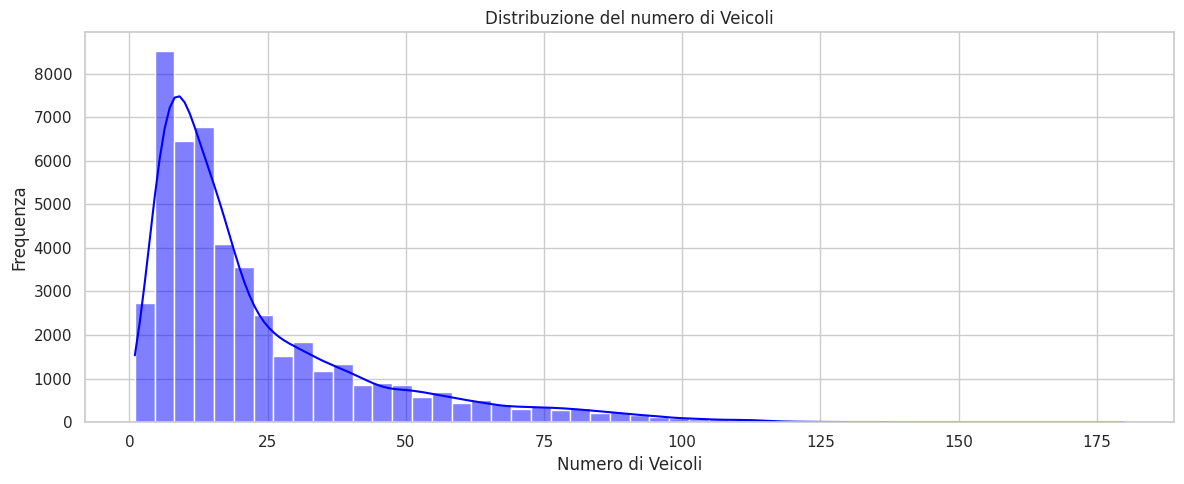

In [56]:
plt.figure(figsize=(12, 5))

# Istogramma
sns.histplot(df['Vehicles'], bins=50, kde=True, color='blue')
plt.title('Distribuzione del numero di Veicoli')
plt.xlabel('Numero di Veicoli')
plt.ylabel('Frequenza')

plt.tight_layout()
plt.savefig('distribution_boxplot.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

La variabile target Vehicles mostra una distribuzione fortemente asimmetrica a destra (right-skewed). La maggior parte dei dati si concentra tra 0 e 50 veicoli per ora. Questo indica che le situazioni di traffico "normale" sono la maggioranza.

### Analisi del Traffico nel Tempo e per Incrocio (Junction)
Verifichiamo come varia il volume di traffico in base agli incroci e alle ore del giorno.

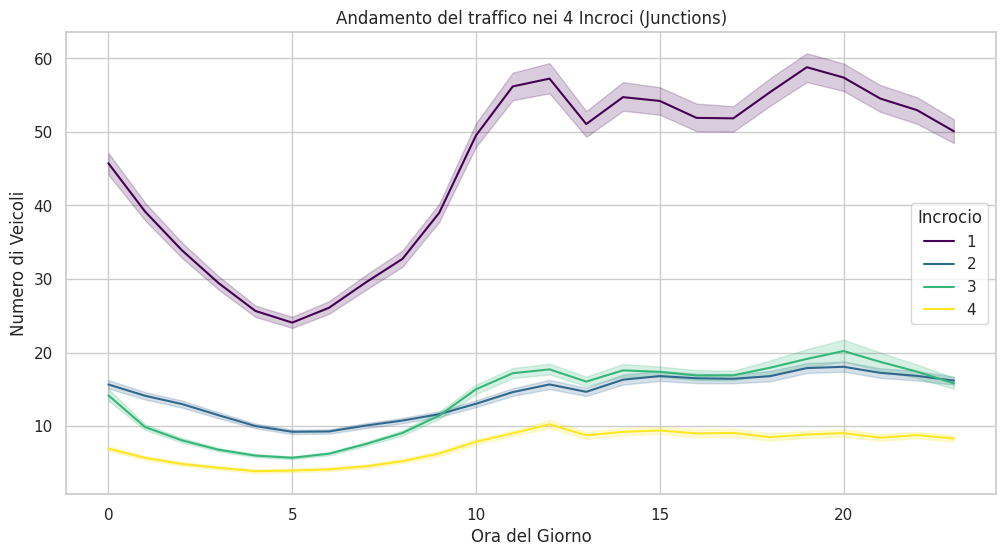

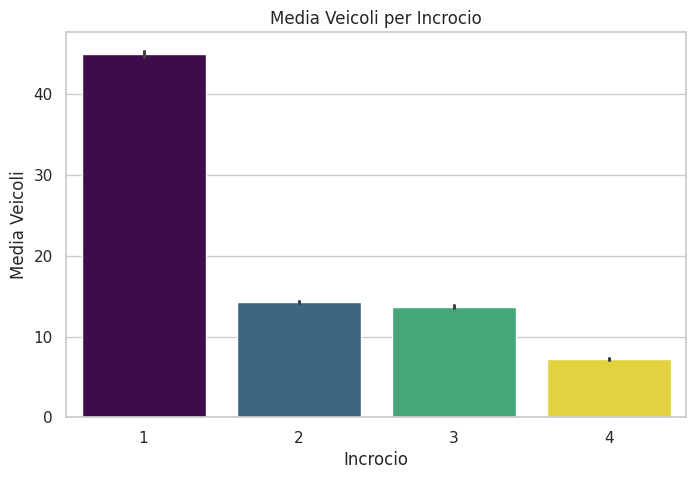

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Creiamo un grafico che mostra l'andamento dei veicoli nel tempo per ogni incrocio
sns.lineplot(data=df, x='Hour', y='Vehicles', hue='Junction', palette='viridis')

plt.title('Andamento del traffico nei 4 Incroci (Junctions)')
plt.xlabel('Ora del Giorno')
plt.ylabel('Numero di Veicoli')
plt.legend(title='Incrocio')
plt.show()

# Facciamo anche un grafico a barre per vedere la media di veicoli per incrocio
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Junction', y='Vehicles', hue="Junction", palette='viridis', legend=False)
#plt.xticks(x, df['Junction'].unique())
plt.title('Media Veicoli per Incrocio')
plt.xlabel('Incrocio')
plt.ylabel('Media Veicoli')
plt.show()

Si nota un evidente picco di traffico nelle ore serali [es. 18:00-19:00] e un calo notturno. L'incrocio 1 risulta essere costantemente il più trafficato

### Matrice di Correlazione
Infine, calcoliamo la correlazione di Pearson tra le variabili numeriche per individuare quali feature sono più linearmente legate al nostro target `Vehicles`.

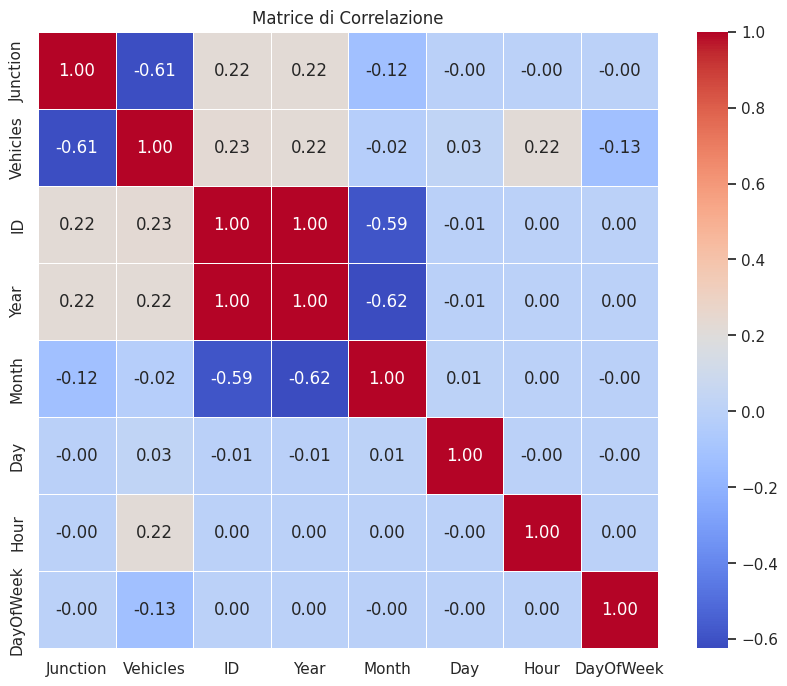

In [58]:
plt.figure(figsize=(10, 8))
# Calcoliamo la correlazione solo sulle colonne numeriche
corr_matrix = df.select_dtypes(include=['number']).corr()

# Disegniamo la heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice di Correlazione')
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

Esiste una forte correlazione negativa (-0.61) tra Junction e Vehicles. Questo conferma che la posizione è il fattore determinante: l'incrocio 1 è strutturalmente molto più trafficato degli altri.

Si nota una correlazione positiva con l'anno (0.22), suggerendo un trend di crescita del traffico nel tempo, e con l'ora (0.20), confermando l'importanza dei cicli giornalieri.

## PREPARAZIONE DATI



Sulla base dell'analisi esplorativa e delle linee guida del progetto, si è proceduto a una prima scrematura delle variabili:

* **Rimozione di `ID`:** Come suggerito dal Punto 1 delle linee guida, la colonna `ID` è stata eliminata in quanto identificatore univoco. Non contenendo alcuna informazione legata ai pattern di traffico, non ha alcun potere predittivo.

* **Rimozione di `Day` e `Month`:** L'analisi della matrice di correlazione ha evidenziato che queste due variabili hanno un impatto quasi nullo sulla variabile target `Vehicles` (correlazione rispettivamente di -0.02 e 0.03). Si è quindi deciso di scartarle per ridurre il "rumore" nei dati, semplificando il modello senza comprometterne la precisione predittiva.

In [59]:
df_final = df.drop(['Day','Month','ID'], axis=1)

display(df_final.head(10))

,Junction,Vehicles,Year,Hour,DayOfWeek
0,1,15,2015,0,6
1,2,6,2015,0,6
2,3,9,2015,0,6
3,3,7,2015,1,6
4,1,13,2015,1,6
5,2,6,2015,1,6
6,2,5,2015,2,6
7,1,10,2015,2,6
8,3,5,2015,2,6
9,2,6,2015,3,6


## PREPARAIONE DEI MODELLI

In [76]:
# 1. Definiamo X e y
X = df_final.drop(['Vehicles'], axis=1)
y = df_final['Vehicles']

# 2. Calcoliamo l'indice per lo split cronologico (70% train, 15% validation, 15% test)
n = len(df_final)
train_index = int(n * 0.8)

# 3. Creiamo i set di Training e Test
X_train = X.iloc[:train_index]
y_train = y.iloc[:train_index]
X_test = X.iloc[train_index:]
y_test = y.iloc[train_index:]

print(f"--- SPLIT CRONOLOGICO EFFETTUATO ---")
print(f"Dati di Allenamento (80%): {X_train.shape[0]} righe")
print(f"Dati di Test (20%): {X_test.shape[0]} righe")

# Verifica rapida: l'ultima riga del train deve venire prima della prima del test
print(f"\nUltimo indice Training: {X_train.index[-1]}")
print(f"Primo indice Test: {X_test.index[0]}")

--- SPLIT CRONOLOGICO EFFETTUATO ---
Dati di Allenamento (80%): 38496 righe
Dati di Test (20%): 9624 righe

Ultimo indice Training: 38495
Primo indice Test: 38496


Per garantire che il modello impari a interpretare i pattern nei dati con capacità di generalizzazione, senza limitarsi a "imparare a memoria" i valori storici (evitando così il rischio di *overfitting*), il dataset è stato suddiviso in due sottoinsiemi distinti:

1. **Training Set (80%):** per l'addestramento dei modelli e la ricerca degli iperparametri.

2. **Test Set (20%):** set isolato utilizzato solo alla fine per valutare le performance.

Poiché stiamo lavorando con dati sequenziali (il traffico nel tempo), durante la ricerca degli iperparametri (Randomized Search) non è stata utilizzata la classica K-Fold Cross Validation (che mischierebbe casualmente passato e futuro), ma una **Time Series Cross-Validation**. Questo assicura che il modello venga sempre validato su dati temporalmente successivi a quelli di training.

# I MODELLI

In [77]:
dizionario = {}
dizionario_modelli = {}

#metodo per valutare i modelli (MAE, R² e pearson coeff)
def model_evaluation(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    re = r2_score(y_true, y_pred)
    coeff,p_value = pearsonr(y_true, y_pred)
    mean_y = np.mean(y_true)
    errore_relativo = (mae / mean_y) * 100

    dizionario[model_name] = {'MAE': mae, 'R2': re, 'Pearson': coeff, 'Errore Relativo': errore_relativo}

    print(f"--- Risultati {model_name} ---")
    print(f"MAE: {mae:.2f}")
    print(f"R²: {re:.2f}")
    print(f"Pearson Coeff: {coeff:.2f}")
    print(f"Errore Relativo: {errore_relativo:.2f}%")
    return mae, re, coeff

### LINEAR REGRESSION

In [78]:
from sklearn.linear_model import LinearRegression


# 1. Creiamo l'istanza del modello
lin_reg = LinearRegression()

# 2. ALLENAMENTO (Fit)
lin_reg.fit(X_train, y_train)

# 3. TEST (Esame)
y_pred_lin = lin_reg.predict(X_val)

#4. STAMPA RISULTATI
print(f"i pesi applicati a junction, year, month, day, hour, dayofweek: {lin_reg.coef_} e l'intercetta: {lin_reg.intercept_}")
mae_lr, r2_lr, coeff_lr = model_evaluation("Regressione Lineare", y_val, y_pred_lin)

i pesi applicati a junction, year, month, day, hour, dayofweek: [-13.44982919  10.69731386   0.60391598  -1.15629321] e l'intercetta: -21520.77632737379
--- Risultati Regressione Lineare ---
MAE: 10.37
R²: 0.63
Pearson Coeff: 0.81
Errore Relativo: 37.97%


## MODELLI DI CLASSIFICAZIONE

### RANDOM FOREST

In [79]:
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(
    n_estimators=1000, #1000 alberi nella foresta
    max_depth=15,
    random_state=42, # rende i risultati riproducibili CIT. GUIDA GALATTICA PER AUTOSTOPPISTI
    min_samples_leaf=5, # Ogni foglia deve avere almeno 5 campioni (riduce overfitting)
    n_jobs=-1 # n_jobs=-1 serve a usare tutti i core
)

# 2. ALLENAMENTO
rf_model.fit(X_train, y_train)

# 3. TEST
y_pred_rf = rf_model.predict(X_val)

#4. STAMPA RISULTATI
mae_rf, r2_rf, coeff_rf = model_evaluation("Random Forest", y_val, y_pred_rf)

--- Risultati Random Forest ---
MAE: 3.76
R²: 0.93
Pearson Coeff: 0.97
Errore Relativo: 13.77%


### XGBOOST

In [80]:
from xgboost import XGBRegressor

# 1. Creiamo il modello XGBoost
xgb_model = XGBRegressor(n_estimators=1000, #   n_estimators=1000 (numero di alberi)
    learning_rate=0.01, #passi che il modello fa per correggere gli errori
    max_depth=8, #nodi massimi per albero
    subsample=0.8, #   subsample=0.8 (ogni albero vede solo l'80% dei dati) cosi da evitare overfitting
    random_state=42,
    n_jobs=-1
)

# 2. ALLENAMENTO
xgb_model.fit(X_train, y_train)

# 3. TEST
y_pred_xgb = xgb_model.predict(X_val)

#4. STAMPA RISULTATI
mae_xgb, r2_xgb, coeff_xgb = model_evaluation("XGBoost", y_val, y_pred_xgb)

--- Risultati XGBoost ---
MAE: 3.76
R²: 0.93
Pearson Coeff: 0.97
Errore Relativo: 13.77%


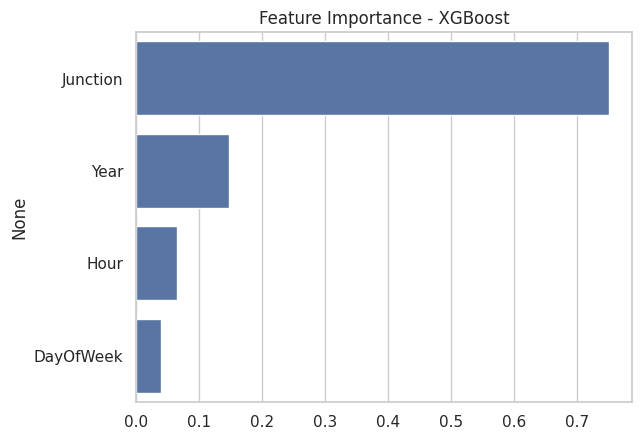

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature_importances = xgb_model.feature_importances_
sns.barplot(x=feature_importances, y=X_train.columns)
plt.title("Feature Importance - XGBoost")
plt.show()

### LIGHTGBM

In [ ]:
from lightgbm import LGBMRegressor

# 1. Configurazione del modello
lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=8,
    num_leaves=50, #numero di foglie totali per albero
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# 2. Allenamento
lgb_model.fit(X_train, y_train)

# 3. Predizione
y_pred_lgb = lgb_model.predict(X_test)

# 4. Valutazione
mae_lgb, r2_lgb, coeff_lgb = model_evaluation("LightGBM", y_test, y_pred_lgb)

--- Risultati LightGBM ---
MAE: 3.79
R²: 0.93
Pearson Coeff: 0.97
Errore Relativo: 13.86%


### KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Utilizzo uno scaler per normalizzare i dati in mdo che i modelli non vengano influenzati da scale diverse tra le variabili

# 1. Configurazione del modello
knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=20, n_jobs=-1)
)

# 2. Allenamento
knn_model.fit(X_train, y_train)

# 3. Predizione
y_pred_knn = knn_model.predict(X_test)

# 4. Valutazione
mae_knn, r2_knn, coeff_knn = model_evaluation("K-Nearest Neighbors", y_test, y_pred_knn)

--- Risultati K-Nearest Neighbors ---
MAE: 4.02
R²: 0.92
Pearson Coeff: 0.96
Errore Relativo: 14.73%


### MLP

In [ ]:
from sklearn.neural_network import MLPRegressor

# 1. Configurazione del modello
mlp_model = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(100, 50), # due strati: uno da 100 hidden layers e uno da 50
        activation='relu', #Se il segnale che arriva al neurone è negativo, lo azzera; se è positivo, lo lascia passare
        solver='adam',
        max_iter=500,
        random_state=42
    )
)

# 2. Allenamento
mlp_model.fit(X_train, y_train)

# 3. Predizione
y_pred_mlp = mlp_model.predict(X_test)

# 4. Valutazione
mae_mlp, r2_mlp, coeff_mlp = model_evaluation("Multi-Layer Perceptron", y_test, y_pred_mlp)

--- Risultati Multi-Layer Perceptron ---
MAE: 3.90
R²: 0.93
Pearson Coeff: 0.96
Errore Relativo: 14.28%


### SVR

In [ ]:
from sklearn.svm import SVR

# 1. Configurazione del modello
svr_model = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf',
        C=100,
        epsilon=0.1,
        cache_size=1000
    )
)

# 2. Allenamento
print("Inizio allenamento SVR...")
svr_model.fit(X_train, y_train)

# 3. Predizione
y_pred_svr = svr_model.predict(X_test)

# 4. Valutazione
mae_svr, r2_svr, coeff_svr = model_evaluation("Support Vector Regression", y_test, y_pred_svr)

Inizio allenamento SVR...
--- Risultati Support Vector Regression ---
MAE: 4.16
R²: 0.91
Pearson Coeff: 0.96
Errore Relativo: 15.23%


# **GRAFICI DEI MODELLI**

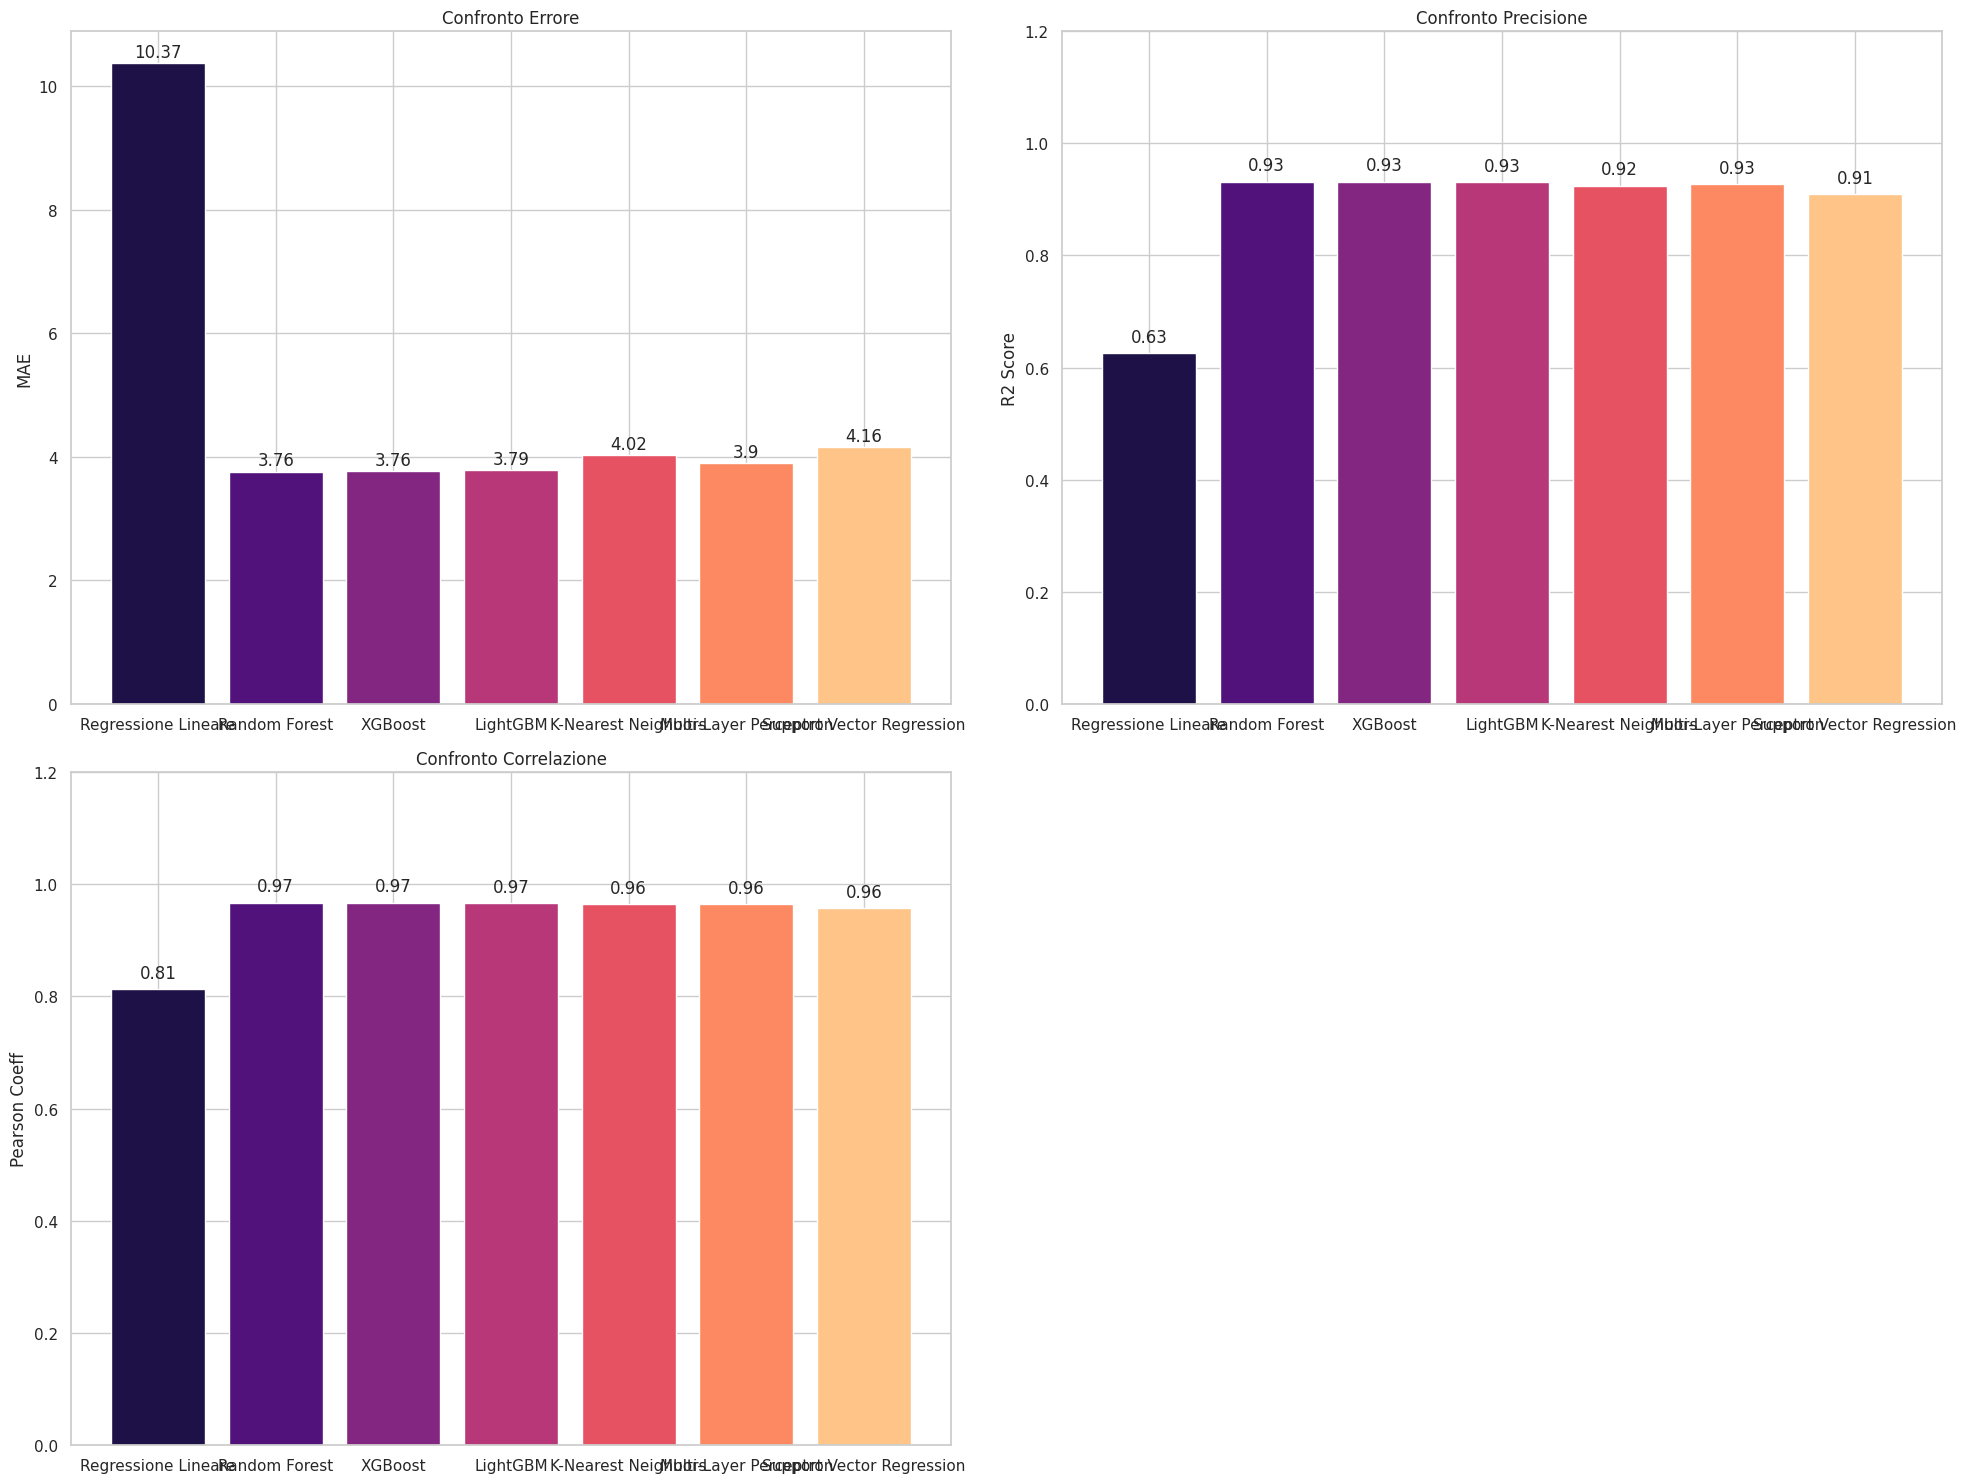

In [86]:
df_results = pd.DataFrame(dizionario).T

modelli = df_results.index
mae_values = df_results['MAE']
r2_values = df_results['R2']
coeff_values = df_results['Pearson']

x = np.arange(len(modelli))
colori = sns.color_palette("magma", len(modelli))

# 1. Grafico per il MAE
plt.figure(figsize=(20, 15))
plt.subplot(2, 2, 1)
bars1 = plt.bar(x, mae_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('MAE')
plt.title('Confronto Errore')
# Aggiunge i numeri sopra le barre
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 2), ha='center')

# 2. Grafico per R2
plt.subplot(2, 2, 2)
bars2 = plt.bar(x, r2_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('R2 Score')
plt.title('Confronto Precisione')
plt.ylim(0, 1.2)
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), ha='center')

# 3. Grafico per il coefficiente di Pearson
plt.subplot(2, 2, 3)
bars3 = plt.bar(x, coeff_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('Pearson Coeff')
plt.title('Confronto Correlazione')
plt.ylim(0, 1.2)
for bar in bars3:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), ha='center')

plt.tight_layout()
plt.show()

## XGBOOST OTTIMIZZATO CON RANDOMIZED SEARCH

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from xgboost import XGBRegressor # Usa XGBClassifier se il tuo fosse un problema di classificazione

# 1. Inizializza il modello base
xgb_model = XGBRegressor(random_state=42)

# 2. Definisci il dizionario dei parametri da esplorare
# Puoi inserire quanti valori vuoi qui dentro, tanto proverà solo combinazioni casuali
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# 3. Creiamo il validatore speciale per le Serie Temporali (sostituisce il Validation Set manuale!)
tscv = TimeSeriesSplit(n_splits=3)

# 3. Configura la Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=20,          # Numero di combinazioni casuali da provare (es. 20 o 30)
    scoring='r2',       # Metrica di valutazione (usa 'neg_mean_squared_error' se preferisci l'MSE)
    cv=tscv,               # Cross-Validation a 3 fold
    verbose=2,          # Stampa l'avanzamento (così vedi che il PC sta lavorando)
    random_state=42,
    n_jobs=-1           # Usa TUTTI i core del tuo processore per fare prima
)

# 4. Avvia l'addestramento
print("Avvio della Randomized Search...")
random_search.fit(X_train, y_train)

# 5. Stampa i risultati
print("\nOttimizzazione completata!")
print("I migliori parametri trovati sono:")
print(random_search.best_params_)

# Puoi salvare automaticamente il modello migliore per fare predizioni
xgb_model_ott = random_search.best_estimator_


Avvio della Randomized Search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=200, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=7, n_estimators=200, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, n_estimators=500, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=7, n_estimators=300, subsample=0.

Per l'ottimizzazione degli iperparametri del modello XGBoost ho scelto di utilizzare la Randomized Search. Data l'elevata quantità di iperparametri di questo algoritmo, una Grid Search esaustiva sarebbe risultata computazionalmente proibitiva. La Randomized Search mi ha permesso di esplorare uno spazio di parametri molto ampio tenendo sotto controllo i tempi di calcolo.

In [91]:
# 1. Predizione con il modello ottimizzato
y_pred_xgb = xgb_model_ott.predict(X_test)

#4. STAMPA RISULTATI
print(f"--- Risultati XGBoost ---")
mae_xgb, r2_xgb, coeff_xgb = model_evaluation("XGBoost_Ottimizzato", y_test, y_pred_xgb)

#5. SALVATAGGIO MODELLO OTTIMIZZATO
model_path_xgb = "./xgb_model_ott.json"
xgb_model_ott.save_model(model_path_xgb)

print(f"Modello XGBoost salvato in: {model_path_xgb}")

--- Risultati XGBoost ---
--- Risultati XGBoost_Ottimizzato ---
MAE: 5.66
R²: 0.90
Pearson Coeff: 0.96
Errore Relativo: 19.32%
Modello XGBoost salvato in: ./xgb_model_ott.json


In [89]:
# 1. Visualizza la storia dell'ottimizzazione
fig1 = optuna.visualization.plot_optimization_history(study)
fig1.show()

# 2. Visualizza l'importanza dei parametri
fig2 = optuna.visualization.plot_param_importances(study)
fig2.show()

NameError: name 'optuna' is not defined

# ONNX

In [ ]:
#Per esportare il modello in ONNX, è necessario rimuovere i metadati dei nomi delle feature
xgb_model_ott.get_booster().feature_names = None

import onnxmltools
from skl2onnx.common.data_types import FloatTensorType

num_features = X_train.shape[1]
initial_type = [('float_input', FloatTensorType([None, num_features]))]

onnx_model = onnxmltools.convert_xgboost(xgb_model_ott, initial_types=initial_type, target_opset=13)

with open("./WebSite/xgb_model_ott.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

# TREELITE

In [ ]:
import treelite, tl2cgen
import os
import contextlib

# 1. Converto
booster = xgb_model_ott.get_booster()
tl_model = treelite.frontend.from_xgboost(booster)

tl2cgen.generate_c_code(
    tl_model,
    dirpath="./model_c_src",
    params={'parallel_comp': 4},
    verbose=False
)

# 2. Compila
with open(os.devnull, 'wb') as devnull:
    with contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
        tl2cgen.export_lib(
            tl_model,
            toolchain="gcc",
            libpath="./xgb_model_ott.so",
            params={'parallel_comp': 4},
            verbose=False
        )


[11:56:59] /tmp/tmpfk5q71dd/libbuild/_deps/treelite-src/src/serializer.cc:202: The model you are loading originated from a newer Treelite version; some functionalities may be unavailable.
Currently running Treelite version 4.1.2
The model checkpoint was generated from Treelite version 4.7.0
[11:56:59] /tmp/tmpfk5q71dd/libbuild/_deps/treelite-src/src/serializer.cc:202: The model you are loading originated from a newer Treelite version; some functionalities may be unavailable.
Currently running Treelite version 4.1.2
The model checkpoint was generated from Treelite version 4.7.0


[11:56:59] /project/src/compiler/ast/split.cc:35: Parallel compilation enabled; member trees will be divided into 4 translation units.


# VALUTAZIONE DEI MODELLI

In [ ]:
import time, os, tracemalloc, cProfile, pstats, gc
from memory_profiler import memory_usage
import onnxruntime as rt
import xgboost as xgb

def tecno_evaluation(model_path, tecno_type):
    n_iters = 1000
    print(f"\n--- ANALISI COMPLETA: {tecno_type.upper()} (su {n_iters} iterazioni) ---")

    load_times = []
    load_peaks = []

    # --- 1. DIMENSIONE FILE ---
    file_size = os.path.getsize(model_path) / (1024 * 1024)
    
    # --- 2. TEMPO DI CARICAMENTO ---
    for n in range(n_iters):
        gc.collect()
        tracemalloc.start()
        start_load = time.perf_counter()
        
        if tecno_type == 'onnx':
            m = rt.InferenceSession(model_path)
        elif tecno_type == 'treelite':
            m = tl2cgen.Predictor(model_path)
        elif tecno_type == 'xgboost':
            m = xgb.XGBRegressor(); m.load_model(model_path)

        load_times.append((time.perf_counter() - start_load) * 1000)
        _, peak_load_ram = tracemalloc.get_traced_memory()
        load_peaks.append(peak_load_ram / 1024)
        tracemalloc.stop()

        if n < n_iters - 1: del m
        else: model_obj = m

    # --- 3. PREDIZIONE ---
    if tecno_type == 'xgboost':
        x_input = X_test.iloc[0:1]
        predict_fn = lambda: model_obj.predict(x_input)
    elif tecno_type == 'onnx':
        x_input = X_test.iloc[0:1].values.astype(np.float32)
        input_name = model_obj.get_inputs()[0].name
        predict_fn = lambda: model_obj.run(None, {input_name: x_input})
    elif tecno_type == 'treelite':
        x_input = tl2cgen.DMatrix(X_test.iloc[0:1].values.astype(np.float32))
        predict_fn = lambda: model_obj.predict(x_input)

    # --- 4. PROFILING CPU ---
    profiler = cProfile.Profile()
    profiler.enable()
    for n in range(100):
        predict_fn()
    profiler.disable()

    # --- 5. TEMPO DI ESECUZIONE ---
    inf_times = []
    for n in range(n_iters):
        t0 = time.perf_counter()
        predict_fn()
        inf_times.append((time.perf_counter() - t0) * 1000)

    # --- 6. USO RAM ---
    import psutil
    process = psutil.Process(os.getpid())
    ram_base = process.memory_info().rss / 1024
    def stress_test():
        for _ in range(n_iters): predict_fn()
    mem_use = memory_usage(stress_test, interval=0.01)
    peak_stress_ram = max(mem_use) * 1024
    delta_ram = max(0, peak_stress_ram - ram_base)

    dizionario_modelli[tecno_type] = {
        "latenza": np.mean(inf_times),
        "latenza_std": np.std(inf_times),
        "throughput": 1000/np.mean(inf_times),
        "ram_delta": delta_ram,
        "file_size": file_size,
        "tempo_di_caricamento": np.mean(load_times),
        "tempo_caricamento_std": np.std(load_times),
        "picco_RAM": np.mean(load_peaks)
    }

    # --- 7. OUTPUT REPORT ---
    print(f"Dimensione file: {file_size:.2f} MB")
    print(f"Tempo caricamento: {np.mean(load_times):.2f} ms (±{np.std(load_times):.2f} ms)")
    print(f"Latenza media: {np.mean(inf_times):.4f} ms (±{np.std(inf_times):.4f} ms)")
    print(f"Throughput: {1000/np.mean(inf_times):.2f} inf/sec")
    print(f"RAM Delta: {delta_ram:.2f} KB")
    print(f"RAM Picco: {np.mean(load_peaks):.2f} KB")

    # Stampa i risultati del profiling
    print("\n--- Top 5 Funzioni per tempo di esecuzione ---")
    stats = pstats.Stats(profiler).sort_stats('cumulative')
    stats.print_stats(5)


In [ ]:
tecno_evaluation("./WebSite/xgb_model_ott.onnx", "onnx")


--- ANALISI COMPLETA: ONNX (su 1000 iterazioni) ---
Dimensione file: 1.05 MB
Tempo caricamento: 12.76 ms (±2.31 ms)
Latenza media: 0.0114 ms (±0.0018 ms)
Throughput: 88080.05 inf/sec
RAM Delta: 0.00 KB
RAM Picco: 2.50 KB

--- Top 5 Funzioni per tempo di esecuzione ---
         314 function calls in 0.002 seconds

   Ordered by: cumulative time
   List reduced from 15 to 5 due to restriction <5>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      100    0.002    0.000    0.002    0.000 /home/matteo-monari/Scrivania/UNI_U/Data_intensive/progetto_data_intensive/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:278(run)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
      100    0.000    0.000    0.000    0.000 /home/matteo-monari/Scrivania/UNI_U/Data_intensive/progetto_data_intensive/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:268(_v

In [ ]:
tecno_evaluation("xgb_model_ott.so", "treelite")


--- ANALISI COMPLETA: TREELITE (su 1000 iterazioni) ---
Dimensione file: 1.09 MB
Tempo caricamento: 0.69 ms (±0.14 ms)
Latenza media: 0.0811 ms (±0.3485 ms)
Throughput: 12326.30 inf/sec
RAM Delta: 0.00 KB
RAM Picco: 3.10 KB

--- Top 5 Funzioni per tempo di esecuzione ---
         2311 function calls in 0.006 seconds

   Ordered by: cumulative time
   List reduced from 22 to 5 due to restriction <5>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      100    0.000    0.000    0.006    0.000 /tmp/ipykernel_14844/2998872495.py:47(<lambda>)
      100    0.005    0.000    0.006    0.000 /home/matteo-monari/Scrivania/UNI_U/Data_intensive/progetto_data_intensive/.venv/lib/python3.12/site-packages/tl2cgen/predictor.py:111(predict)
      100    0.000    0.000    0.001    0.000 /home/matteo-monari/Scrivania/UNI_U/Data_intensive/progetto_data_intensive/.venv/lib/python3.12/site-packages/numpy/ctypeslib/_ctypeslib.py:520(as_array)
      100    0.000    0.000    0.000    

In [ ]:
tecno_evaluation("xgb_model_ott.json", "xgboost")


--- ANALISI COMPLETA: XGBOOST (su 1000 iterazioni) ---
Dimensione file: 2.05 MB
Tempo caricamento: 56.40 ms (±3.53 ms)
Latenza media: 2.1503 ms (±1.6302 ms)
Throughput: 465.06 inf/sec
RAM Delta: 0.00 KB
RAM Picco: 16.74 KB

--- Top 5 Funzioni per tempo di esecuzione ---
         247809 function calls (243109 primitive calls) in 0.350 seconds

   Ordered by: cumulative time
   List reduced from 297 to 5 due to restriction <5>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      100    0.000    0.000    0.350    0.003 /tmp/ipykernel_14844/2998872495.py:40(<lambda>)
  200/100    0.002    0.000    0.350    0.003 /home/matteo-monari/Scrivania/UNI_U/Data_intensive/progetto_data_intensive/.venv/lib/python3.12/site-packages/xgboost/core.py:732(inner_f)
      100    0.001    0.000    0.349    0.003 /home/matteo-monari/Scrivania/UNI_U/Data_intensive/progetto_data_intensive/.venv/lib/python3.12/site-packages/xgboost/sklearn.py:1401(predict)
      100    0.114    0.001  

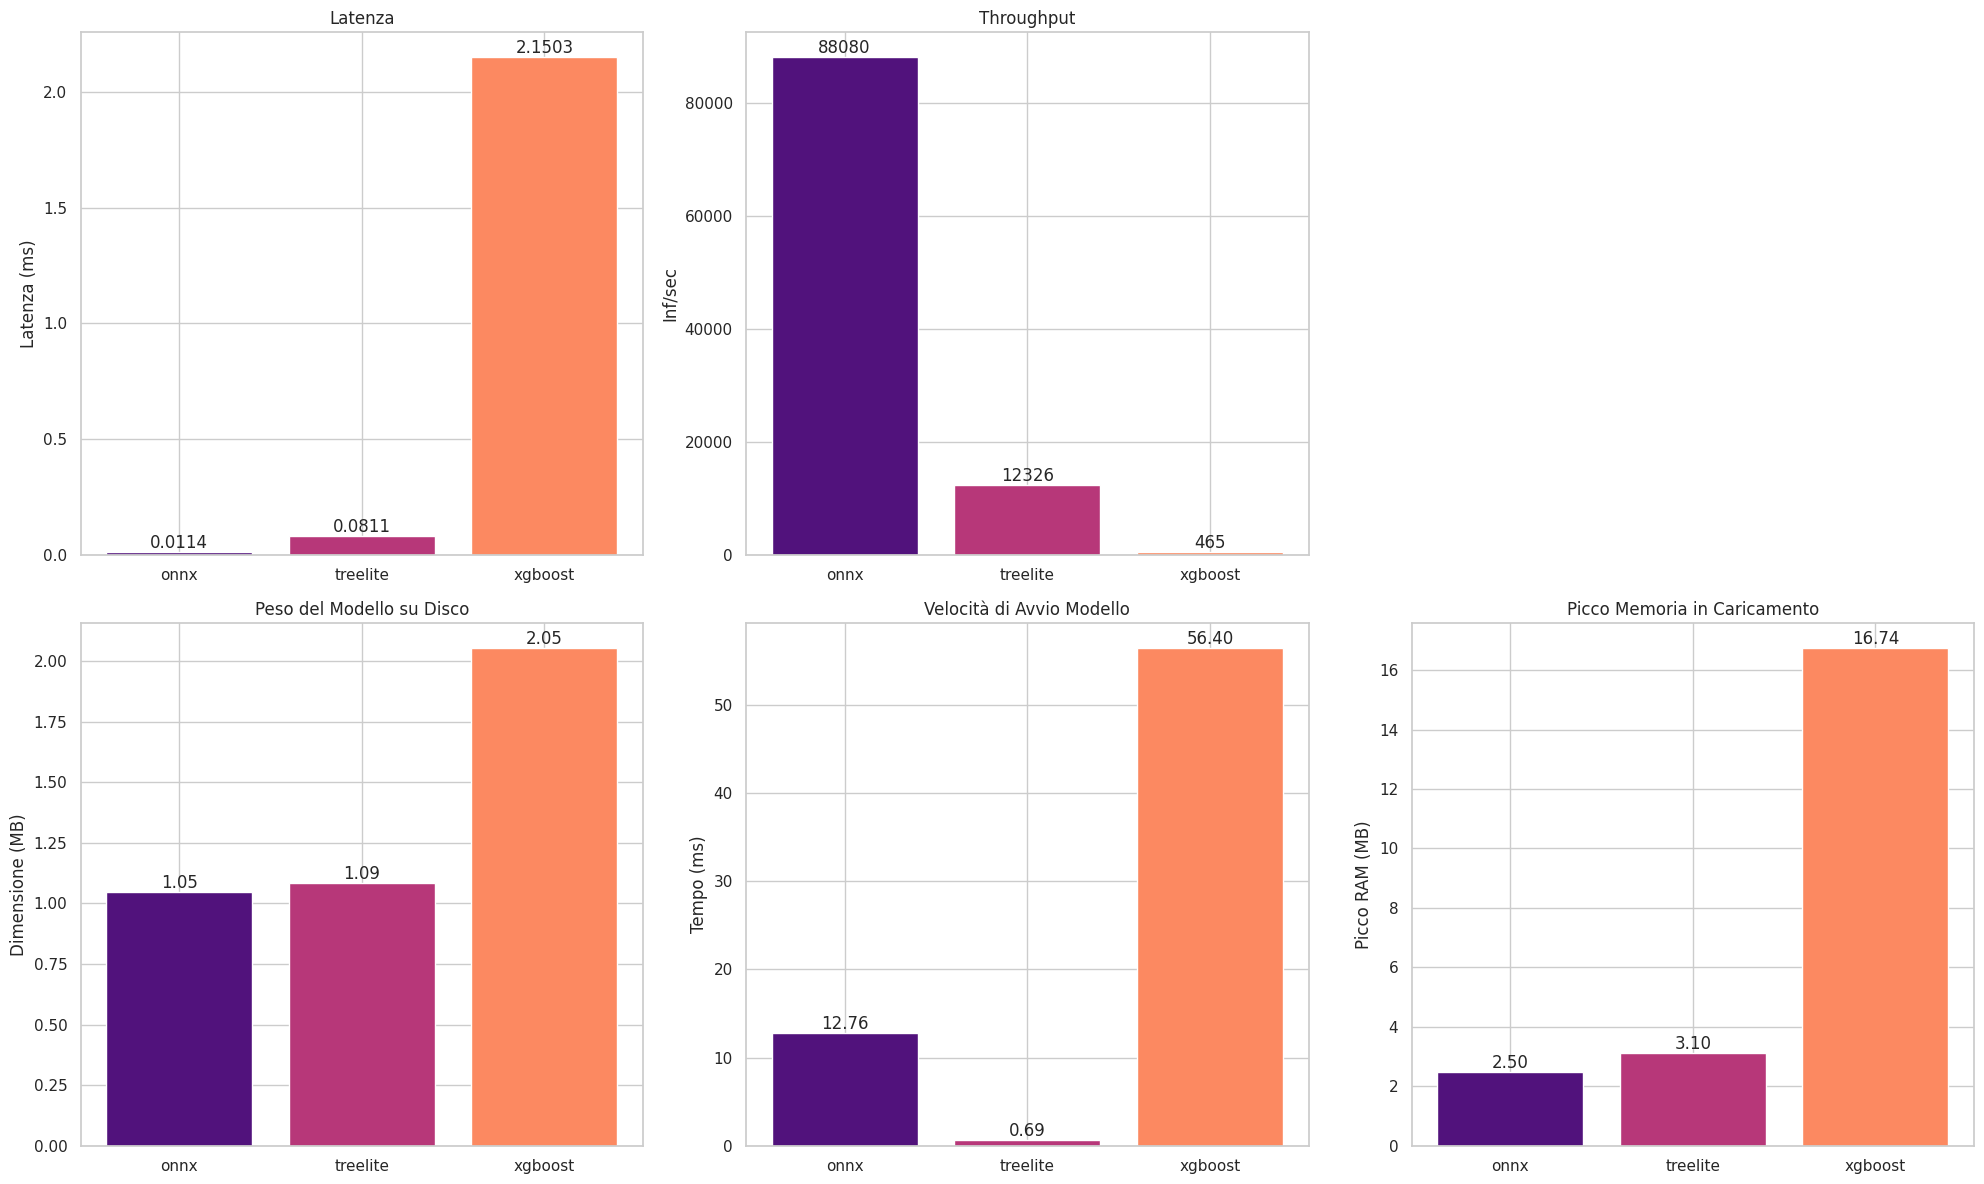

In [ ]:
df_results = pd.DataFrame(dizionario_modelli).T

modelli = df_results.index
latenza_values = df_results['latenza']
throughput_values = df_results['throughput']
ram_delta_values = df_results['ram_delta']
file_size_values = df_results['file_size']
tempo_di_caricamento_values = df_results['tempo_di_caricamento']
picco_RAM_values = df_results['picco_RAM']

x = np.arange(len(modelli))
colori = sns.color_palette("magma", len(modelli))

plt.figure(figsize=(20, 12))

# 1. Latenza
plt.subplot(2, 3, 1)
bars1 = plt.bar(x, latenza_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('Latenza (ms)')
plt.title('Latenza')
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}', ha='center', va='bottom')

# 2. Throughput
plt.subplot(2, 3, 2)
bars2 = plt.bar(x, throughput_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('Inf/sec')
plt.title('Throughput')
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval)}', ha='center', va='bottom')

# 4. File Size
plt.subplot(2, 3, 4)
bars4 = plt.bar(x, file_size_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('Dimensione (MB)')
plt.title('Peso del Modello su Disco')
for bar in bars4:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom')

# 5. Tempo di Caricamento
plt.subplot(2, 3, 5)
bars5 = plt.bar(x, tempo_di_caricamento_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('Tempo (ms)')
plt.title('Velocità di Avvio Modello')
for bar in bars5:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom')

# 6. Picco RAM
plt.subplot(2, 3, 6)
bars6 = plt.bar(x, picco_RAM_values, color=colori)
plt.xticks(x, modelli)
plt.ylabel('Picco RAM (MB)')
plt.title('Picco Memoria in Caricamento')
for bar in bars6:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom')

#plt.savefig('grafici.png', dpi=300, bbox_inches='tight', transparent=True)
plt.tight_layout()
plt.show()